# Study 778 — Chipotle-Scare 🌯🦠

*For the curious.* Every few years a headline breaks that a Chipotle location poisoned its customers — E. coli, norovirus, Salmonella — the stock craters, and somebody on finance Twitter says *buy the dip, the burritos will be back*. We put **six real Chipotle food-safety scares** (2015→2018) on the stand and asked the tape one plain question: **if you buy CMG the day the scare goes public, do you get paid?** The answer is a hard no — and in a direction that should scare *you*.

## The claim, and why it's a clean test

A food-safety scare is *unscheduled* — you can't front-run it. But once the news is public you absolutely *can* buy the panic. So *buy at the announcement close, hold K sessions* is executable and zero-look-ahead by construction. We measure CMG's **abnormal** return (CMG − SPY, total-return) so we're grading the burrito, not the market. Two loud caveats up front: **n = 6**, and four of those six are the *same* 2015 contamination crisis — so this is a story, not a statistic.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from chipotle_scare import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching CMG + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} scares resolved")


panel loaded; 6 of 6 scares resolved


## The six scares we test (hardcoded from CDC / health depts / coverage)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['year', 'anchor_date', 'what broke'])

,year,anchor_date,what broke
0,2015,2015-09-17,"Minnesota Salmonella Newport (tomatoes, 64 sic..."
1,2015,2015-11-02,"E. coli O26, WA/OR — Chipotle closes 43 restau..."
2,2015,2015-12-04,"CDC announces a second, genetically distinct E..."
3,2015,2015-12-08,"Boston College norovirus (~140 sickened, incl...."
4,2017,2017-07-18,"Sterling, VA norovirus (~135 sickened); CMG fe..."
5,2018,2018-08-01,"Powell, OH Clostridium perfringens (~647 sicke..."


## The picture: mean cumulative abnormal return around the scare

Offset 0 is the day the scare went public. Left of zero is the run-in (the dip forming); right of zero is the *buy-the-dip* window. If the folklore were right, the line would turn **up** after zero.

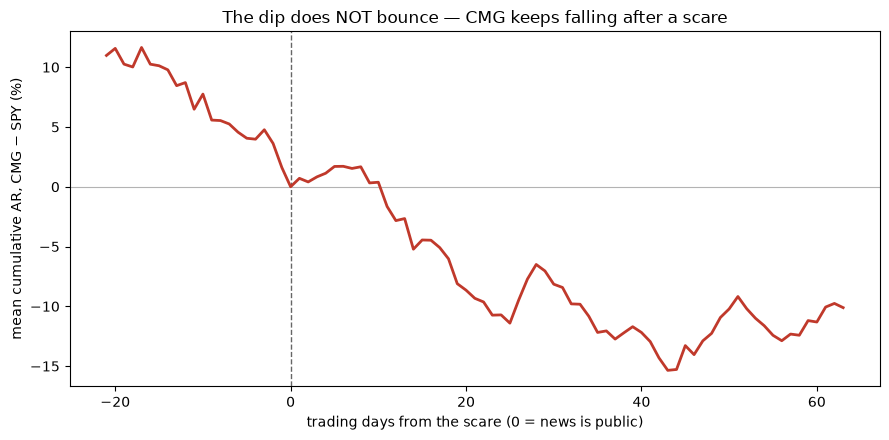

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#c0392b', lw=2)
ax.set_xlabel('trading days from the scare (0 = news is public)')
ax.set_ylabel('mean cumulative AR, CMG − SPY (%)')
ax.set_title('The dip does NOT bounce — CMG keeps falling after a scare')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week shock (into the news) | -3.88% | -3.45 | 0/6 |
| 1-month shock | -9.81% | -2.64 | 1/6 |
| **1-month rebound (buy the dip)** | **-9.33%** | **-2.35** | 1/6 |
| 1-quarter rebound | -10.11% | -1.88 | 1/6 |

The scare is a real dip — CMG lost ~3.9% vs SPY in the week *into* the news (0 of 6 events positive). But the 'buy the dip' half is **inverted**: in the month *after* the scare CMG fell another **9.3%** (*t* = -2.35). Only 1 of 6 scares (Powell, OH 2018) rewarded the dip-buyer; the rest kept bleeding.

In [4]:
rows = [('2wk shock','pre_s'),('1mo shock','pre_l'),('1mo rebound','post_s'),('1q rebound','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk shock    n= 6  mean=-3.877%  t=-3.451  hit 0/6
1mo shock    n= 6  mean=-9.806%  t=-2.640  hit 1/6
1mo rebound  n= 6  mean=-9.329%  t=-2.355  hit 1/6
1q rebound   n= 6  mean=-10.111%  t=-1.877  hit 1/6


## So what?

The famous *buy the dip on a Chipotle scare* trade is a **falling knife**: the scare is not a one-day repricing but the start of a slow bleed (spectacularly so in the 2015 crisis, which dragged for months). The one comforting number — a *t* of −2.36 on the keep-falling drift — is a mirage of small samples: four of six events are one autocorrelated 2015 episode. Verdict: **Weak signal, Mirage tradability** — you can't bank a 6-event, one-crisis curiosity, and the folklore as stated loses money. The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.